In [2438]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import shutil
from sensor_fusion import kalman_filters, height
from collections import deque

In [2439]:
TIMESTAMPS = 'timestamp'

ACCELERATION = 'acceleration'
MODEL_VELOCITY = 'model_velocity'
MODEL_DISPLACEMENT = 'model_displacement'

PRESSURE = 'pressure'
BAROMETER_HEIGHT = 'barometer_height'

BAROMETER_LEVELS = 'barometer_levels'
STAGES = 'stages'

TRUE_DISPLACEMENT = 'true_displacement'
TRUE_VELOCITY = 'true_velocity'

In [2440]:
import configparser

# Initialize the parser
config = configparser.ConfigParser()

# Read the config file
config.read('config.ini')

ACCELERATION_SMOOTHING = config['processing'].getfloat('acceleration_smoothing')
BAROMETER_SMOOTHING = config['processing'].getfloat('barometer_smoothing')
LOWER_ACC_THRESHOLD = config['processing'].getfloat('lower_acc_threshold')
UPPER_ACC_THRESHOLD = config['processing'].getfloat('upper_acc_threshold')
C_LIM = config['processing'].getint('c_lim')

In [2441]:
# def load_data(path):
#     """
#     Loads the the data into a dataframe
#     @params
#     path: where the data to analyse is
#     """
#     df = pd.read_csv(path)

#     if df[TIMESTAMPS].iloc[0] > 0:
#         df[TIMESTAMPS] = (df[TIMESTAMPS] - df['timestamp'].iloc[0]) / 1000
    
#     df['raw_acceleration'] = df['acceleration']
    
#     return df

We will only work with the df['acc'] column as this will allow us to change it to just acc_z in the future if need be

In [2442]:
def save_df(df, path, number):
    """
    Saves the dataframe
    @params
    df: dataframe
    path: the path to save the df to
    name: 
    """
    os.makedirs(path, exist_ok=True)
    df.to_csv(f"{path}/{number}.csv", index=False)

In [2443]:
def drift_correction(df, col, bound):
    """
    Removes the offset on the acceleration
    @params
    df: dataframe
    bound: how much the function will accept a lack of significant movement
    """
    rolling_sum = 0
    num_of_pnts = 0
    for acc in df[col]:
        if acc == df[col].iloc[0] or abs(rolling_sum / num_of_pnts - acc) < bound:
            rolling_sum += acc
            num_of_pnts += 1
    df[col] -= rolling_sum / num_of_pnts


In [2444]:
# def smooth(df, col, SMOOTHING):
#     """
#     Smooths data values (also add small lag)
#     @params
#     df: dataframe
#     col: column name to smooth
    
#     """

#     smoothed_values = []
#     prev = None
#     for row in df[col]:

#         if prev is None:
#             smoothed_value = row
#         else:
#             smoothed_value = (prev + SMOOTHING * row) / (1 + SMOOTHING)
        
#         prev = smoothed_value
#         smoothed_values.append(smoothed_value)

#     df[col] = smoothed_values


In [2445]:
def correct_vel_at_stationary(df, effect):
    """
    When stage == 0, reduce velocity to 0 by effect
    @params
    df: dataframe
    col: column name
    effect: how much to reduce at each timestep
    """
    assert "stages" in df.columns, "stages needs to be in the dataframe"
    assert MODEL_VELOCITY in df.columns, f"{MODEL_VELOCITY} needs to be in the dataframe"
    for i in range(len(df)):

        if df['stages'].iloc[i] == 0:
            if df[MODEL_VELOCITY].iloc[i] > effect:
                df.loc[i:, [MODEL_VELOCITY]] = df.loc[i:, [MODEL_VELOCITY]] - effect
            elif df[MODEL_VELOCITY].iloc[i] < - effect:
                df.loc[i:, [MODEL_VELOCITY]] = df.loc[i:, [MODEL_VELOCITY]] + effect
                    

In [2446]:

def barometer_height_snap_to_floor(df):
    assert STAGES in df.columns, f"{STAGES} needs to be in the dataframe"
    df[BAROMETER_LEVELS] = pd.NA

    floors = [0]

    i = 0
    while i < len(df):
        height_data = []
        while i < len(df) and (not len(height_data) or df[STAGES].iloc[i] == 0):
            if df[STAGES].iloc[i] == 0: height_data.append(df[BAROMETER_HEIGHT].iloc[i])
            i += 1

        if (len(height_data) <= 4): continue

        np_floors = np.array(floors)
        height_data = np.array(height_data)
        height_data = height_data[int(len(height_data) * 0.25):int(len(height_data) * 0.75)]
        height = np.mean(height_data)
        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif < 1:
            abs_min_index = np.argmin(np.abs(floor_height_differences) - abs_min_floor_height_dif)
            df.loc[i - len(height_data):, [BAROMETER_HEIGHT]] = df.loc[i - len(height_data):, [BAROMETER_HEIGHT]] + floor_height_differences[abs_min_index]

            df.loc[i - len(height_data):i, [BAROMETER_LEVELS]] = np_floors[abs_min_index]

        else:
            floors.append(float(height))
            df.loc[i - len(height_data):i, [BAROMETER_LEVELS]] = float(height)
            
    return floors
        
    

In [2447]:
def differentiate(df, u, v, new_name):
    """
    Differentiation of u by v
    @params:
    u, v: du/dv
    new_name: resulting column name
    """
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        du = df[u].iloc[i] - df[u].iloc[i - 1]
        dv = df[v].iloc[i] - df[v].iloc[i - 1]

        if dv != 0:
            df.at[i, new_name] = du / dv

In [2448]:
def integrate(df, u, v, new_name):
    """
    Integration of u by v
    @params:
    df: dataframe
    u, v: ∫ u dv
    new_name: resulting columns name
    """
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        avg_u = (df[u].iloc[i] + df[u].iloc[i - 1]) / 2
        dv = df[v].iloc[i] - df[v].iloc[i - 1]
        
        df.at[i, new_name] = df[new_name].iloc[i - 1] + avg_u * dv

In [2449]:
def add_stages(df, LB, UB, col, prefix):
    """
    Attaches stages to the dataframe based off of values on lable col,
    stages change at threshold values based off of LB & UB
    @params:
    df: datframe
    LB: Lower Bound (0-1)
    UB: Upper Bound (0-1)
    col: label to base stages off of
    prefix: unique for result label on df
    
    """
    max_acc = max(df[col])
    min_acc = min(df[col])
    new_col = prefix + "Stages"

    pos_a_lt = LB * max_acc
    pos_a_ut = UB * max_acc

    neg_a_lt = LB * min_acc
    neg_a_ut = UB * min_acc

    df[new_col] = 0
    C = 0
    Clim = 10
    up = False
    down = False
    i = 0
    while i < len(df):
        acc = df[col].iloc[i]
        curr_stage = df[new_col].iloc[i]

        if curr_stage in [0, 2] and (acc > pos_a_ut or acc < neg_a_ut):
            C += 1
            up = True
        elif curr_stage in [1, 3] and (acc < pos_a_lt and acc > neg_a_lt):
            C += 1
            down = True
        else:
            C = 0
            up = False
            down = False
        
        if C >= Clim and (up or down):
            j = i
            while (
                (up and (df[col].iloc[j] > pos_a_lt or df[col].iloc[j] < neg_a_lt))
                or (down and (df[col].iloc[j] < pos_a_lt and df[col].iloc[j] > neg_a_lt))
            ):
                j -= 1
                
            df.loc[j:, [new_col]] = (df[new_col].iloc[i] + 1) % 4
            i = j # May remove later
        
        i += 1
            


In [2450]:
def linear_offset(df, label, offset, start, stop):
    """
    time-dependent correction or transformation of the label values,
    with the offset controlling how much change happens across the time range
    @params
    df: dataframe
    label: column name to edit
    offset: 
    start: 
    stop: 
    """
    dt = df[TIMESTAMPS].iloc[stop] - df[TIMESTAMPS].iloc[start]
    for i in range(start, stop + 1):
        df.at[i, label] = df[label].iloc[i] - offset * ((df[TIMESTAMPS].iloc[i] - df[TIMESTAMPS].iloc[start]) / dt)
    
# def linear_offset_avoid_stationary(df, label, offset, start, stop):
#     """
#     time-dependent correction or transformation of the label values,
#     with the offset controlling how much change happens across the time range
#     @params
#     df: dataframe
#     label: column name to edit
#     offset: 
#     start: 
#     stop: 
#     """
#     moving_time = 0
#     cumulative_moving_time = {}  # Maps index to cumulative moving time
#     last_timestamp = df[TIMESTAMPS].iloc[start]
#     current_moving_time = 0
    
#     for i in range(start + 1, stop + 1):
#         current_dt = df[TIMESTAMPS].iloc[i] - last_timestamp
        
#         # If we're moving (not stationary), add to our moving time
#         if df[STAGES].iloc[i] != 0:
#             moving_time += current_dt
#             current_moving_time += current_dt
            
#         # Store the cumulative moving time up to this point
#         cumulative_moving_time[i] = current_moving_time
#         last_timestamp = df[TIMESTAMPS].iloc[i]
    
#     # If we have no moving time, avoid division by zero
#     if moving_time == 0:
#         return
        
#     # Second pass: apply corrections based on moving time only
#     last_valid_i = start
#     for i in range(start, stop + 1):
#         if df[STAGES].iloc[i] != 0:  # Only modify non-stationary points
#             # Calculate what fraction of moving time has passed
#             last_valid_i = i
#             time_fraction = cumulative_moving_time.get(i, 0) / moving_time
#             # Apply proportional correction
#             df.at[i, label] = df[label].iloc[i] - (offset * time_fraction)
#         else:
#             time_fraction = cumulative_moving_time.get(last_valid_i, 0) / moving_time
#             # Apply proportional correction
#             df.at[i, label] = df[label].iloc[i] - (offset * time_fraction)

In [2451]:
def sign(v):
    return 1 if v > 0 else -1

def correct_vel(df):

    i = 0
    while i < len(df):
        start = i
        stop = i

        while i < len(df) - 1 and df[STAGES].iloc[i] in [0, 2]:
            stop += 1
            i += 1
        
        if start != stop:
            offset = df[MODEL_VELOCITY].iloc[stop] - df[MODEL_VELOCITY].iloc[start]
            linear_offset(df, MODEL_VELOCITY, offset, start, stop)
            df.loc[stop + 1:, [MODEL_VELOCITY]] -= offset
        i += 1

    i = 0
    direction = 0
    while i < len(df):
        
        start = i
        stop = i

        if df[STAGES].iloc[i] == 1:
            direction = sign(df[MODEL_VELOCITY].iloc[i])

        while df[STAGES].iloc[i] in [2, 3] and sign(df[MODEL_VELOCITY].iloc[i]) != direction:
            # stop += 1
            df.loc[i:, [MODEL_VELOCITY]] -= df[MODEL_VELOCITY].iloc[i]
            i += 1

        # if start != stop:
        #     offset = df[col].iloc[stop] - df[col].iloc[start]
        #     linear_offset(df, col, offset, start - 1, stop)
        #     df.loc[stop + 1:, [col]] -= offset
        
        i += 1


In [2452]:
def correct_height_at_stationary(df, height_label):
    i = 0
    while i < len(df):
        start = i
        stop = i

        while i < len(df) - 1 and df[STAGES].iloc[i] == 0:
            stop += 1
            i += 1
        
        if start != stop:
            offset = df[height_label].iloc[stop] - df[height_label].iloc[start]
            linear_offset(df, height_label, offset, start, stop)
            df.loc[stop + 1:, [height_label]] -= offset
        i += 1

def correct_height_from_barometer_levels(df, height_label):
    i = 1
    while i < len(df):

        journeys_checked = 0

        j = i - 1
        if df[STAGES].iloc[j] == 0 and df[STAGES].iloc[i] == 1:
            
            curr_level = df[BAROMETER_LEVELS].iloc[j]
            stationary_start = None
            previous_journey = None

            while j > 1 and journeys_checked < 6:

                if previous_journey == None and df[STAGES].iloc[j - 1] == 0 and df[STAGES].iloc[j] == 1:
                    previous_journey = j

                if stationary_start == None and df[STAGES].iloc[j - 1] == 3 and df[STAGES].iloc[j] == 0:
                    stationary_start = j

                if df[STAGES].iloc[j - 1] == 0 and df[STAGES].iloc[j] == 1:

                    if df[BAROMETER_LEVELS].iloc[j - 1] == curr_level:

                        k = j - 1
                        cum_sum = 0
                        while k > 0 and df[STAGES].iloc[k] == 0:
                            cum_sum += df[height_label].iloc[k]
                            k -= 1

                        offset = df[height_label].iloc[(stationary_start + i) // 2] - (cum_sum / (j - 1 - k))
                        linear_offset(df, height_label, offset, previous_journey, stationary_start)
                        df.loc[stationary_start + 1:, [height_label]] -= offset
                        break
                    journeys_checked += 1

                j -= 1

        i += 1

In [2453]:
def get_dist(df, col, start, end):
    """
    Gets mean and variance of sample of col in df from start to end
    @params
    df: dataframe
    col: column name
    start: beginning of calculation
    end: end of calculation
    """
    mean = df.loc[start:end, col].mean()
    var_sum = 0
    for i in range(start, end):
        var_sum += (df[col].iloc[i] - mean) ** 2
    return mean, var_sum / (end - start - 1)

In [2454]:
def single_correct_height_and_get_floors(df, height_label):
    assert STAGES in df.columns, f"{STAGES} needs to be in the dataframe"
    assert height_label in df.columns, f"{height_label} needs to be in the dataframe"
    floors = [0]

    i = 0
    while i < len(df):
        height_data = []
        while i < len(df) and (not len(height_data) or df[STAGES].iloc[i] == 0):
            if df[STAGES].iloc[i] == 0:
                height_data.append(df[height_label].iloc[i])
            i += 1

        if (len(height_data) <= 4): continue

        np_floors = np.array(floors)
        height_data = np.array(height_data)
        height_data = height_data[int(len(height_data) * 0.25):int(len(height_data) * 0.75)]
        height = np.mean(height_data)
        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif < 1.2:
            abs_min_index = np.argmin(np.abs(floor_height_differences) - abs_min_floor_height_dif)
            df.loc[i - len(height_data):, [height_label]] = df.loc[i - len(height_data):, [height_label]] + floor_height_differences[abs_min_index]
        else:
            floors.append(float(height))
        
    return floors
        

In [2455]:
def proporionate_correct_and_get_floors(df, height1_label, height2_label):
    assert 'aStages' in df.columns, "aStages needs to be in the dataframe"
    assert height1_label in df.columns, f"{height1_label} needs to be in the dataframe"
    assert height2_label in df.columns, f"{height2_label} needs to be in the dataframe"
    floors = [0]

    i = 0
    while i < len(df):
        height1_data = []
        height2_data = []
        while i < len(df) and (not len(height1_data) or df['aStages'].iloc[i] == 0):
            if df['aStages'].iloc[i] == 0:
                height1_data.append(df[height1_label].iloc[i])
                height2_data.append(df[height2_label].iloc[i])
            i += 1

        if (len(height1_data) <= 4 or len(height2_data) <= 4): continue

        height1_data = height1_data[int(len(height1_data) * 0.25):int(len(height1_data) * 0.75)]
        height2_data = height2_data[int(len(height2_data) * 0.25):int(len(height2_data) * 0.75)]

        np_floors = np.array(floors)

        # Determine whether or not it is a new floor
        height_data = (np.array(height1_data) * 0.8 + np.array(height2_data) * 0.2) # True height estimate
        height = np.mean(height_data)

        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif > 1.2:

            floors.append(float(height))
            
            np_floors = np.array(floors)
            floor_height_differences = np_floors - height
            abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        floor_index = np.argmin(np.abs(floor_height_differences - height))
        # Move height1 to match with true height
        floor_height1_differences = np_floors - np.mean(height1_data)
        offset1 = floor_height1_differences[floor_index]
        df.loc[i - len(height1_data):, [height1_label]] = df.loc[i - len(height1_data):, [height1_label]] + offset1

        #Move height2 to match with true height
        floor_height2_differences = np_floors - np.mean(height2_data)
        offset2 = floor_height2_differences[floor_index]
        df.loc[i - len(height2_data):, [height2_label]] = df.loc[i - len(height2_data):, [height2_label]] + offset2
        
    return floors

In [2456]:
def dependant_correction_and_get_floors(df, height1_label, height2_label):

    """
    
    """

    assert 'aStages' in df.columns, "aStages needs to be in the dataframe"
    assert height1_label in df.columns, f"{height1_label} needs to be in the dataframe"
    assert height2_label in df.columns, f"{height2_label} needs to be in the dataframe"
    floors = [0]
    dependant_floors = [0]

    i = 0
    previous_stationary_point = 0
    while i < len(df):
        height1_data = []
        height2_data = []
        while i < len(df) and (not len(height1_data) or df['aStages'].iloc[i] == 0):
            if df['aStages'].iloc[i] == 0:
                height1_data.append(df[height1_label].iloc[i])
                height2_data.append(df[height2_label].iloc[i])
            i += 1

        if (len(height1_data) <= 4 or len(height2_data) <= 4): continue

        height1_data = height1_data[int(len(height1_data) * 0.25):int(len(height1_data) * 0.75)]
        height2_data = height2_data[int(len(height2_data) * 0.25):int(len(height2_data) * 0.75)]

        np_floors = np.array(floors)
        height = np.mean(height1_data)

        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif > 1.2:

            floors.append(float(height))
            dependant_floors.append(float(np.mean(height2_data)))
            
            np_floors = np.array(floors)
            floor_height_differences = np_floors - height
            abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))
        
        floor_index = np.argmin(np.abs(floor_height_differences - height))
        start_stationary_index = i - 2 * len(height1_data)
        # Move height1 to match with floor height
        floor_height1_differences = np_floors - np.mean(height1_data)
        offset1 = floor_height1_differences[floor_index]
        df.loc[start_stationary_index:, [height1_label]] = df.loc[start_stationary_index:, [height1_label]] + offset1
        linear_offset(df, height1_label, - offset1, previous_stationary_point, start_stationary_index)

        #Move height2 to match with floor height
        floor_height2_differences = np.array(dependant_floors) - np.mean(height2_data)
        offset2 = floor_height2_differences[floor_index]
        df.loc[start_stationary_index:, [height2_label]] = df.loc[start_stationary_index:, [height2_label]] + offset2
        linear_offset(df, height2_label, - offset2, previous_stationary_point, start_stationary_index)

        previous_stationary_point = i

    return (floors, dependant_floors)

In [2457]:
def get_floors(df, col):

    """
    Gets the stationary values in col at stage 0,
    then groups the ones which are close to one another
    """

    potential_floors = []
    floor_indexes = []
    round_1dp = lambda x: int(x * 10) / 10
    
    i = 0
    while i < len(df):

        if df['aStages'].iloc[i] == 0:

            standing_height = []
            while i < len(df) and df['aStages'].iloc[i] == 0:
                standing_height.append(df[col].iloc[i])
                i += 1

            standing_height = np.array(standing_height)

            start = int(len(standing_height) * 0.25)
            end = int(len(standing_height) * 0.75)

            potential_floors.append(
                round_1dp(standing_height[start:end].mean())
            )
            floor_indexes.append((start, end))

        i += 1

    floor_clusters = []
    floor_var = 1 # floor height of 2m
    for i in range(len(potential_floors)):
        floor = potential_floors[i]

        for cluster in floor_clusters:

            if abs(np.mean(cluster) - floor) < floor_var:
                cluster.append(floor)
                break
        else:
            floor_clusters.append([floor])
    
    return [np.mean(cluster) for cluster in floor_clusters]
    


In [2458]:
def get_relative_stages(df, maxlen=20, 
                           no_change_threshold=0.5):
    rolling_average = deque(maxlen=maxlen)
    for i in range(maxlen):
        rolling_average.append(df[MODEL_VELOCITY].iloc[i])
    
    curr_stage = 0
    df[STAGES] = 0
    
    for i in range(maxlen, len(df)):
        # Get current velocity and calculate rolling average
        current_vel = df[MODEL_VELOCITY].iloc[i]
        prev_avg = sum(rolling_average) / maxlen
        rolling_average.append(current_vel)
        new_avg = sum(rolling_average) / maxlen
        
        dv = new_avg - prev_avg

        if curr_stage in [1, 3] and abs(dv) < no_change_threshold:
            curr_stage = (curr_stage + 1) % 4
            df.loc[max(i - maxlen // 10, 0):, [STAGES]] = curr_stage
            
        if curr_stage in [0, 2] and abs(dv) > no_change_threshold:
            curr_stage = (curr_stage + 1) % 4
            df.loc[max(i - maxlen // 1.5, 0):, [STAGES]] = curr_stage

    return df

    

In [2459]:
def get_true_values(df, accelerometer_variance, barometer_variance):

    """
    Integrates the kalman filter to predict better values by combining the sensors
    @params
    df: dataframe with data
    accelerometer_variance: The variance of the accelerometer
    barometer_variance: The variance of the barometer
    """
    
    df[TRUE_DISPLACEMENT] = None
    df[TRUE_VELOCITY] = None
    kf = kalman_filters.KalmanFilter(0, 0, accelerometer_variance, barometer_variance)
    for i in df.index:

        if not i:
            dt = df[TIMESTAMPS].iloc[0]
        else:
            dt = (df[TIMESTAMPS].iloc[i] - df[TIMESTAMPS].iloc[i - 1])

        # kf.predict_with_accelerometer(df[ACCELERATION].iloc[i], dt)
        kf.predict_with_state(df[MODEL_DISPLACEMENT].iloc[i], df[MODEL_VELOCITY].iloc[i], dt)

        # kf.update_with_model(df['model_height'], df['model_velocity'])
        kf.update_with_barometer(df[BAROMETER_HEIGHT].iloc[i])

        height, velocity = kf.get_estimate()
        df.loc[i, TRUE_DISPLACEMENT] = height
        df.loc[i, TRUE_VELOCITY] = velocity
    

In [2460]:
def smooth_kalman(df, col, variance):
    kf = kalman_filters.SingleValueKalmanFilter(0, variance)
    smoothed = []
    for i in df.index:
        v = df[col].iloc[i]

        if not i:
            dt = df[TIMESTAMPS].iloc[0]
        else:
            dt = (df[TIMESTAMPS].iloc[i] - df[TIMESTAMPS].iloc[i - 1])

        smoothed.append(kf.update(v, dt))
    
    df[col] = smoothed

In [2461]:


# save_dir = "./analysed/"

# for item in os.listdir(save_dir):
#     item_path = os.path.join(save_dir, item)
#     if os.path.isfile(item_path) or os.path.islink(item_path):
#         os.remove(item_path)
#     elif os.path.isdir(item_path):
#         shutil.rmtree(item_path)

# datastreams = "./datastreams"
# folders = os.listdir(datastreams)
# dtype = [('timestamp', 'int32'), ('acceleration', 'float32'), ('pressure', 'float32')]
# FREQUENCY = 10
# data_size_from_mins = lambda mins : int(FREQUENCY * 60 * mins)
# data_shape = (data_size_from_mins(10),)
# increment = 5

# for folder in folders:
#     path = f"{datastreams}/{folder}"
#     curr_data = []
#     journey = 0
#     data_file = 0
#     while data_file < len(os.listdir(path)):
#         data_path = f"{path}/{data_file}.dat"
#         prev_data_file = data_file
#         data = np.memmap(data_path, dtype=dtype, mode='r', shape=data_shape)
#         start = 0
#         end = increment

#         while end <= data_shape[0]:
#             if data_file != prev_data_file:
#                 prev_data_file = data_file
#                 data_path = f"{path}/{data_file}.dat"
#                 data = np.memmap(data_file, dtype=dtype, mode='r', shape=data_shape)

#             curr_data.extend(data[start:end])
#             df = pd.DataFrame(np.array(curr_data, dtype=dtype), columns=['timestamp', 'acceleration'])
#             df['raw_acceleration'] = df['acceleration']
#             df['timestamp'] -= df['timestamp'].iloc[0]

#             # var_a = (acc_smooth * var_raw_acc) / (2 + acc_smooth)
#             smooth(df, 'acceleration', ACCELERATION_SMOOTHING)
#             drift_correction(df, bound=0.02)

#             add_stages(df, LOWER_ACC_THRESHOLD, UPPER_ACC_THRESHOLD, 'acceleration', 'a')

#             first_one_index = df[df['aStages'] == 1].index.min()
#             if df['aStages'].iloc[-1] != 1 or not pd.notna(first_one_index):
#                 end += increment
#                 start += increment
#                 continue

#             df_slice = df.iloc[first_one_index + 1:]
#             zeros_after = df_slice[df_slice['aStages'] == 0]
#             if not zeros_after.empty:
#                 zero_after_one_index = zeros_after.index.min()

#             if zeros_after.empty or not pd.notna(zero_after_one_index):
#                 end += increment
#                 start += increment
#                 continue
            
#             print("Journey found!")
#             # Found the journey
#             half_stationary = (len(df) - zero_after_one_index) // 2

#             df = df[:-half_stationary]
#             if half_stationary > end:
#                 data_file -= 1
            
#             end = (end - half_stationary) % data_shape[0]
#             start = (start - half_stationary) % data_shape[0]

#             curr_data.clear()
#             start = end
#             end += min(increment, data_shape[0] - end)

#             mean, acc_var = get_dist(df, 'raw_acceleration', 0, df[df['aStages'] == 1].index[0])

#             differentiate(df, 'acceleration', 'timestamp', 'jerk')

#             #velocity variance = Sum 0...n: ((dt ** 2) / 2) * acc_var
#             integrate(df, 'acceleration', 'timestamp', 'model_velocity')

#             # Velocity variance resets to 0 at each stationary location
#             correct_vel_at_stationary(df, 'model_velocity', 0.0005)

#             # Height variance = Sum 0...n: ((dt ** 2) / 2) * velocity variance
#             integrate(df, 'model_velocity', 'timestamp', 'model_height')
            
#             # get_true_values(df, acc_var, 0)
                
#             save_df(df, save_dir + folder, journey)
#             journey += 1
        
#         data_file += 1


In [2462]:
save_dir = "./analysed/"

for item in os.listdir(save_dir):
    item_path = os.path.join(save_dir, item)
    if os.path.isfile(item_path) or os.path.islink(item_path):
        os.remove(item_path)
    elif os.path.isdir(item_path):
        shutil.rmtree(item_path)

datastreams = "./datastreams"
folder = os.listdir(datastreams)[0]
dtype = [('timestamp', 'int32'), ('acceleration', 'float32'), ('pressure', 'float32')]
FREQUENCY = 10
data_size_from_mins = lambda mins : int(FREQUENCY * 60 * mins)
data_shape = (data_size_from_mins(10),)

data_path = f"{datastreams}/{os.listdir(datastreams)[0]}/0.dat"
data = np.memmap(data_path, dtype=dtype, mode='r', shape=data_shape)

df = pd.DataFrame(data, columns=['timestamp', 'acceleration', 'pressure'])
df[ACCELERATION] = df['acceleration']

drift_correction(df, ACCELERATION, bound=0.02)

df = df[df[TIMESTAMPS] != 0]
df.reset_index(drop=True, inplace=True)
df[TIMESTAMPS] -= df[TIMESTAMPS].iloc[0]
df[TIMESTAMPS] /= 1000

smooth_kalman(df, ACCELERATION, 0.2)

integrate(df, ACCELERATION, TIMESTAMPS, MODEL_VELOCITY)
get_relative_stages(df, maxlen=20, no_change_threshold=0.005)

correct_vel(df)
correct_vel_at_stationary(df, 0.015)


integrate(df, MODEL_VELOCITY, TIMESTAMPS, MODEL_DISPLACEMENT)

_, acc_var = get_dist(df, ACCELERATION, 0, df[df[STAGES] == 1].index[0])


df[BAROMETER_HEIGHT] = df[PRESSURE].apply(height.calculate_height)
bar_mean, bar_var = get_dist(df, BAROMETER_HEIGHT, 0, df[df[STAGES] == 1].index[0])
# df['barometer_height'] -= bar_mean
drift_correction(df, BAROMETER_HEIGHT, bound=0.5)
smooth_kalman(df, BAROMETER_HEIGHT, bar_var)
barometer_height_snap_to_floor(df)
df[BAROMETER_HEIGHT] /= 3.1

correct_height_at_stationary(df, MODEL_DISPLACEMENT)
correct_height_from_barometer_levels(df, MODEL_DISPLACEMENT)


get_true_values(df, acc_varS, bar_var)
    
save_df(df, save_dir + folder, "bob")


In [2463]:
def chart(col1, col2=None):
    fig, ax1 = plt.subplots()

    labels = {
        ACCELERATION: 'Acceleration (m/s^2)',
        MODEL_DISPLACEMENT: 'Height (m)',
        MODEL_VELOCITY: 'Velocity (m/s)',
        STAGES: "stages",
        BAROMETER_LEVELS: "bar levels",
        TRUE_DISPLACEMENT: "True Height (m)",
        BAROMETER_HEIGHT: "Barometer Height (m)",
        TRUE_VELOCITY: "True Velocity (m/s)"
    }
    col1_label = labels[col1]

    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(col1_label, color='tab:blue')

    ax1.plot(df['timestamp'], df[col1], color='tab:blue', label=col1)
    ax1.tick_params(axis='y', labelcolor='tab:blue')   
    plt.axhline(y=0, color='r', linestyle='--', label='y=0')

    if col2 != None:
        ax2 = ax1.twinx()
        ax2.set_ylabel(col2, color='tab:red')

        ax2.plot(df['timestamp'], df[col2], color='tab:red', label=col2)
        ax2.tick_params(axis='y', labelcolor='tab:red')

        minimum = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
        maximum = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
        ax1.set_ylim(minimum, maximum)
        ax2.set_ylim(minimum, maximum)

        plt.title(f'{col1_label} and {col2} vs. Time')
    
    else:
        plt.title(f'{col1_label} vs. Time') 

    fig.tight_layout()

    plt.show()

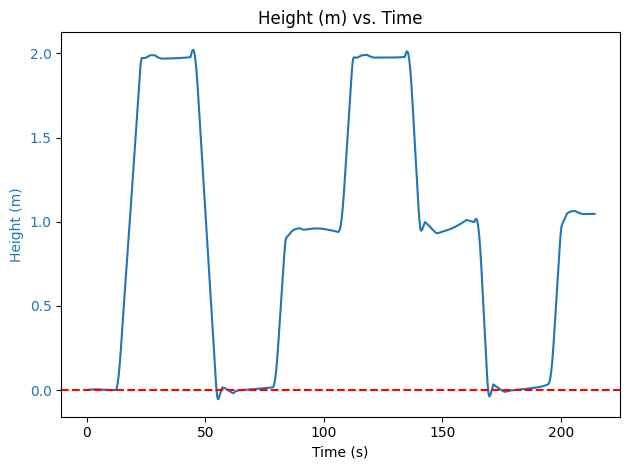

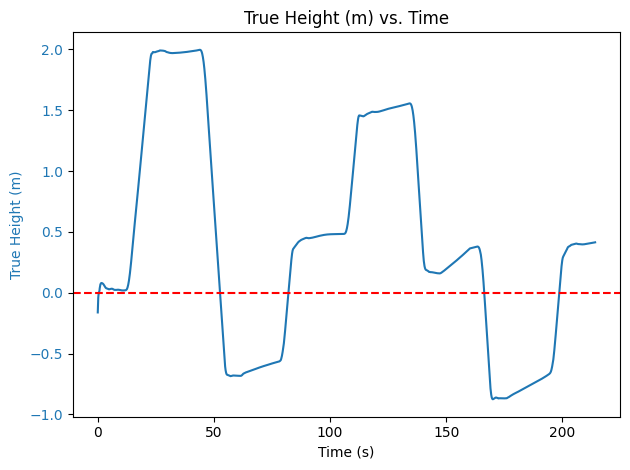

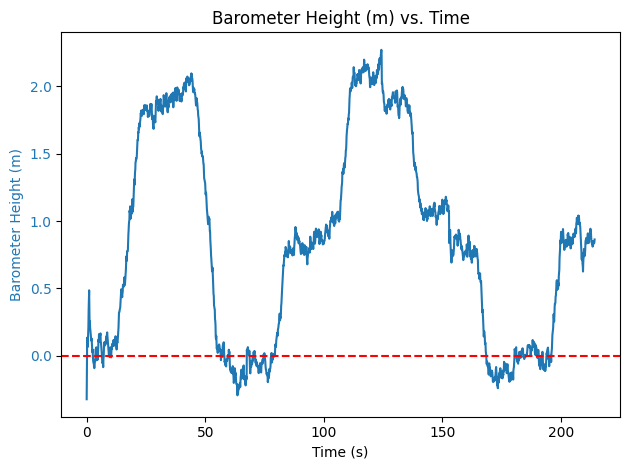

In [2464]:
# correct_height_at_stationary(df, TRUE_DISPLACEMENT)
# correct_height_from_barometer_levels(df, TRUE_DISPLACEMENT)
# df = df[400:750]
chart(MODEL_DISPLACEMENT)
# chart(TRUE_VELOCITY)

# chart(MODEL_VELOCITY)

chart(TRUE_DISPLACEMENT)
chart(BAROMETER_HEIGHT)
